# Satellite Evolution in Linear Tide

In this example, we will simulate the evolution of a satellite galaxy under the linear terms of the MW halo's tidal field to see if it is expected to disrupt at this radius.

### Setting Up

Let's consider the host galaxy to be the NFW halo component of galpy's `MWPotential2014`

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [76]:
from galpy.potential import MWPotential2014

pot = MWPotential2014[2]
pot.turn_physical_on()

pot

NFWPotential with internal parameters: amp=4.852230533527998, a=2.0 and physical outputs fully on, using ro=8.0 kpc and vo=220.0 km/s

To isolate the linear order effects of the tide, we can set up a tambora {class}`~tambora.dynamics.forces.external_force.LinearTideGalpyForce`.

In [77]:
from tambora.dynamics import LinearTideGalpyForce

linear_tide = LinearTideGalpyForce(pot, center=None)

With `center=None`, this force will automatically compute the first order term of the tidal force at the median location of the provided positions. 

Now, we can set up the simulation and add the linear tide as an external force.

In [78]:
from tambora.simulation import Sim

mysim = Sim()
mysim.add_external_force(linear_tide)

Lastly, we just need to create the progenitor and add it to `mysim`. Let's make the progenitor a $10^8$ $\text{M}_{\odot}$ Plummer sphere with a scale radius of 0.5 kpc, positioned 20 kpc from the center of the host. 

We can use tambora's built-in sampling tools to sample 5k particles.

In [79]:
from tambora.tools import mkPlummer_galpy

# --- Sample Particles ------------------------------------------- #
pos, vel, mass = mkPlummer_galpy(m=1e8, b=0.5, n=10_000, center_pos=[20, 0, 0])

# --- add to mysim ----------------------------------------------- #
mysim.add_particles('sat', pos, vel, mass)

In [80]:
import astropy.units as u

# tidal radius from galpy
rtide = pot.rtide(R=20*u.kpc, z=0., phi=0., 
                  M=1e8*u.Msun, quantity=True)

# particle positions from mysim
x, y = mysim.x(0), mysim.y(0)

# linear tide accelerations
external_ax = mysim.external_ax(0)
external_ay = mysim.external_ay(0)

# self-gravity accelerations
self_ax = mysim.self_ax(0, method='falcON', eps=0.1) 
self_ay = mysim.self_ay(0, method='falcON', eps=0.1)

# net accelerations
net_ax = self_ax + external_ax
net_ay = self_ay + external_ay

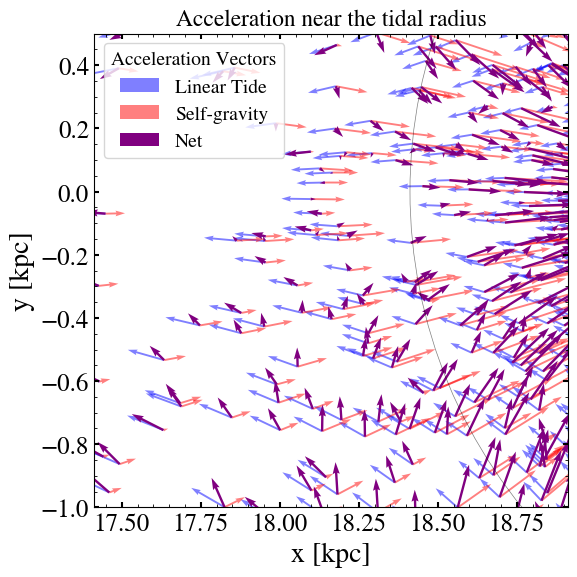

In [83]:
from tambora.tools import mkPlummer_galpy
import warnings

# pos, vel, mass = mkPlummer_galpy(m=1e8, b=2., n=10_000, center_pos=[20, 0, 0], center_vel=[0, 220, 0])

# tidal_acc = nfw_field.acc(pos, 0.0)

import matplotlib.pyplot as plt
skip = 1
plt.figure(figsize=(6, 6))
plt.quiver(
    mysim.x(0)[::skip],
    mysim.y(0)[::skip],
    mysim.external_ax(0)[::skip],
    mysim.external_ay(0)[::skip],
    angles='xy',
    scale_units='xy',
    scale=1000.,
    width=0.004,
    alpha=0.5,
    color='blue',
    label='Linear Tide'
)

plt.quiver(
    mysim.x(0)[::skip],
    mysim.y(0)[::skip],
    mysim.self_ax(0, method='falcON', eps=0.1)[::skip],
    mysim.self_ay(0, method='falcON', eps=0.1)[::skip],
    angles='xy',
    scale_units='xy',
    scale=1000.,
    width=0.004,
    alpha=0.5,
    color='r',
    label='Self-gravity'

)

plt.quiver(
    mysim.x(0)[::skip],
    mysim.y(0)[::skip],
    mysim.self_ax(0, method='falcON', eps=0.1)[::skip] + mysim.external_ax(0)[::skip],
    mysim.self_ay(0, method='falcON', eps=0.1)[::skip] + mysim.external_ay(0)[::skip],
    angles='xy',
    scale_units='xy',
    scale=1000.,
    width=0.005,
    alpha=1.0,
    color='purple',
    label='Net'
)
circle = Circle((20, 0), float(rtide.value), edgecolor='black', facecolor='none', linewidth=0.5, alpha=0.5)

plt.gca().add_patch(circle)
plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.title("Acceleration near the tidal radius")
# plt.axis("equal")
plt.xlim(20 - rtide.value - 1.0, 20 - rtide.value + 0.5)
plt.ylim(-1.0, 0.5)
plt.legend(loc='upper left', title='Acceleration Vectors')
plt.tight_layout()
plt.show()

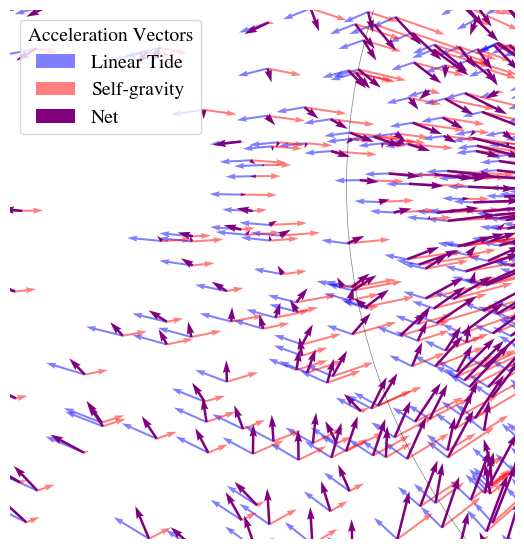

In [114]:
from tambora.tools import mkPlummer_galpy
import warnings

# pos, vel, mass = mkPlummer_galpy(m=1e8, b=2., n=10_000, center_pos=[20, 0, 0], center_vel=[0, 220, 0])

# tidal_acc = nfw_field.acc(pos, 0.0)

import matplotlib.pyplot as plt
skip = 1
plt.figure(figsize=(6, 6))
plt.quiver(
    mysim.x(0)[::skip],
    mysim.y(0)[::skip],
    mysim.external_ax(0)[::skip],
    mysim.external_ay(0)[::skip],
    angles='xy',
    scale_units='xy',
    scale=1000.,
    width=0.004,
    alpha=0.5,
    color='blue',
    label='Linear Tide'
)

plt.quiver(
    mysim.x(0)[::skip],
    mysim.y(0)[::skip],
    mysim.self_ax(0, method='falcON', eps=0.1)[::skip],
    mysim.self_ay(0, method='falcON', eps=0.1)[::skip],
    angles='xy',
    scale_units='xy',
    scale=1000.,
    width=0.004,
    alpha=0.5,
    color='r',
    label='Self-gravity'

)

plt.quiver(
    mysim.x(0)[::skip],
    mysim.y(0)[::skip],
    mysim.self_ax(0, method='falcON', eps=0.1)[::skip] + mysim.external_ax(0)[::skip],
    mysim.self_ay(0, method='falcON', eps=0.1)[::skip] + mysim.external_ay(0)[::skip],
    angles='xy',
    scale_units='xy',
    scale=1000.,
    width=0.005,
    alpha=1.0,
    color='purple',
    label='Net'
)
circle = Circle((20, 0), float(rtide.value), edgecolor='black', facecolor='none', linewidth=0.5, alpha=0.5)

plt.gca().add_patch(circle)
# plt.axis("equal")
plt.xlim(20 - rtide.value - 1.0, 20 - rtide.value + 0.5)
plt.ylim(-1.0, 0.5)
plt.legend(loc='upper left', title='Acceleration Vectors')
plt.tight_layout()
plt.axis('off')
plt.savefig('acceleration_vecs.png', dpi=200)
plt.show()

### Running the Simulation

Let's run the simulation for a Gyr.

In [108]:
mysim.run(t_end=0.5, dt=0.005, dt_out=0.01, eps=0.1)

100%|██████████| 100/100 [00:02<00:00, 42.90it/s]


### Analyzing the Simulation

We can use the same position accessors as before to get the time-evolution of the particle positions. 

In [109]:
# the default time argument is ..., 
# which returns all times

x_ev, y_ev = mysim.x(), mysim.y()

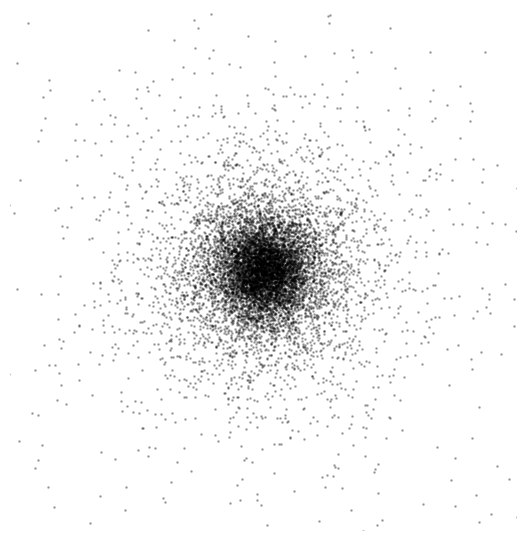

In [110]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Get the time steps from the simulation
times = mysim.times

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

#circle = Circle((x, 0), float(rtide.value), edgecolor='black', facecolor='none', linewidth=1.0, alpha=0.5)
def animate(frame):
    frame *= 1
    ax.clear()
    ax.scatter(mysim.x(frame), mysim.y(frame), alpha=0.25, s=1, c='k')
    #ax.set_xlabel("x [kpc]", fontsize=20)
    #ax.set_ylabel("y [kpc]", fontsize=20)
    #ax.set_title(f"t = {times[frame]:.2f} Gyr", fontsize=22)
    #ax.set_aspect('equal')
    # ax.set_xlim(mysim.x(0).min() - 2, mysim.x(0).max() + 2)
    # ax.set_ylim(mysim.y(0).min() - 2, mysim.y(0).max() + 2)
    # ax.add_patch(circle)
    ax.set_xlim(20-2*rtide.value, 20+2*rtide.value)
    ax.set_ylim(-2*rtide.value, 2*rtide.value)
    ax.set_axis_off()
fig.tight_layout()

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(times)//1, interval=0.5, repeat=True)
#plt.tight_layout()
anim.save('sat_in_linear_tide.gif')

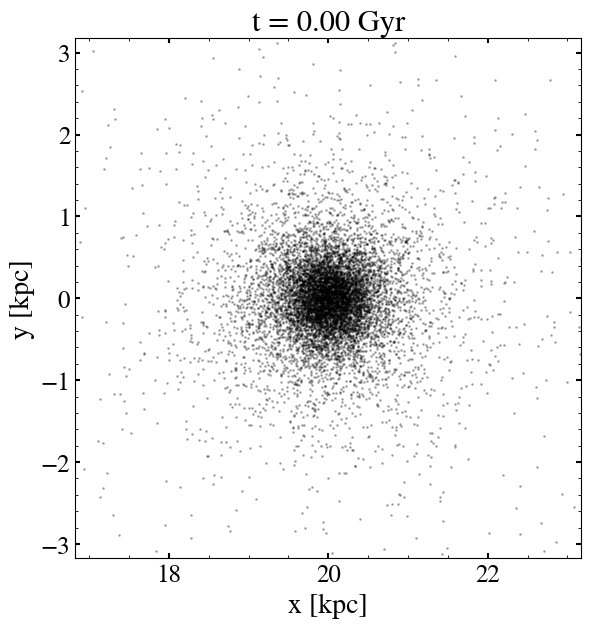

In [111]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Get the time steps from the simulation
times = mysim.times

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

#circle = Circle((x, 0), float(rtide.value), edgecolor='black', facecolor='none', linewidth=1.0, alpha=0.5)
def animate(frame):
    frame *= 1
    ax.clear()
    ax.scatter(mysim.x(frame), mysim.y(frame), alpha=0.25, s=1, c='k')
    ax.set_xlabel("x [kpc]", fontsize=20)
    ax.set_ylabel("y [kpc]", fontsize=20)
    ax.set_title(f"t = {times[frame]:.2f} Gyr", fontsize=22)
    #ax.set_aspect('equal')
    # ax.set_xlim(mysim.x(0).min() - 2, mysim.x(0).max() + 2)
    # ax.set_ylim(mysim.y(0).min() - 2, mysim.y(0).max() + 2)
    # ax.add_patch(circle)
    ax.set_xlim(20-2*rtide.value, 20+2*rtide.value)
    ax.set_ylim(-2*rtide.value, 2*rtide.value)

fig.tight_layout()

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(times)//1, interval=0.5, repeat=True)
#plt.tight_layout()
anim.save('sat_in_linear_tide_with_axes.gif')

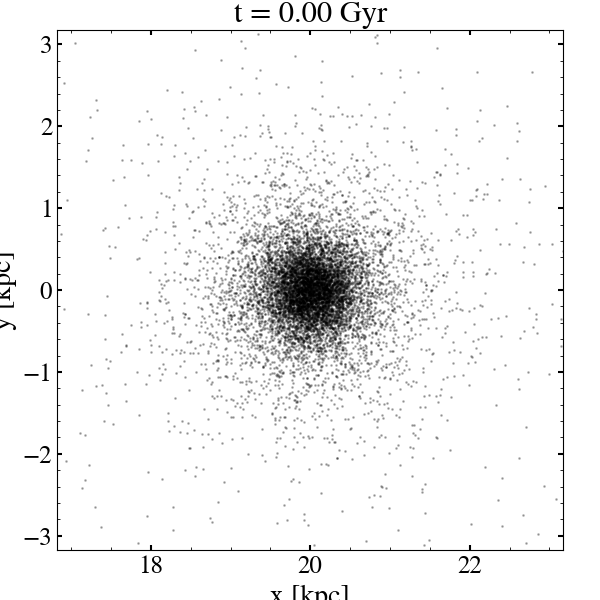

In [113]:
from IPython.display import Image
Image('sat_in_linear_tide_with_axes.gif', embed=True)